# Analyse des retards — simulation GAMA

Ce notebook analyse les retards d'arrivée des agents dans une run de simulation,
en croisant les logs GAMA avec les données de population enrichie.

## Ce que fait ce notebook

1. **Charge** les enregistrements d'arrivée (`gama_arrivals.csv`) produits par GAMA pour une expérience donnée
2. **Identifie** les agents en retard de plus de 15 minutes à au moins une activité
3. **Formate** les timestamps et retards pour la lecture humaine
4. **Inspecte** un agent spécifique : tableau de ses activités avec les temps de trajet OSMnx par mode
5. **Visualise** la journée complète d'un agent sur un diagramme de Gantt 24h

## Données en entrée

- `experiments/<run>/gama_results/gama_arrivals.csv` — arrivées enregistrées par GAMA (person_id, activity, arrive_at, expected_arrive_at, delay_s)
- `experiments/<run>/population_<N>.json` — population enrichie (activités + itinéraires OSMnx)

## Paramètre principal

`LOG_DIR` : chemin vers le dossier de l'expérience à analyser — **à modifier selon la run souhaitée**

In [1]:
import pandas as pd

# Dossier de l'expérience à analyser — modifier selon la run souhaitée
LOG_DIR = '../../experiments/current/'

# Chargement des enregistrements d'arrivée produits par GAMA
# Colonnes attendues : person_id, activity_purpose, arrive_at, expected_arrive_at, delay_s
df = pd.read_csv(LOG_DIR + 'gama_results/gama_arrivals.csv')
df

,move_id,person_id,arrive_at,expected_arrive_at,delay_s,started_at,schedule_at,departure_delay_s,timed_out
0,7aa15bc9-2d59-4cc4-9501-8055675b4613,1170603,1773639805,1773640259,-454,1.773637e+09,1773639359,-2157.0,False
1,c504d404-484b-4117-af29-4c068a109533,387324,1773640807,1773640807,0,1.773637e+09,1773639308,-2106.0,False
2,6020bc7e-8faf-4857-9796-14b58af1f87f,1170603,1773642129,1773642452,-323,1.773640e+09,1773641552,-1743.0,False
3,0f079ea7-407a-4827-b919-296235b9fc18,1412568,1773642748,1773642751,-3,1.773637e+09,1773640829,-3627.0,False
4,e779c469-63dd-464d-826d-7876cfd18a57,1405560,1773643189,1773643192,-3,1.773637e+09,1773641379,-4177.0,False
...,...,...,...,...,...,...,...,...,...
3658,c8f53dbf-8b3d-426e-920a-7089c8967876,386877,1774778615,1774778615,0,1.774703e+09,1774775742,-72530.0,False
3659,59efe851-7ac5-44c8-9d56-b4aefe562f24,740296,1774778761,1774779231,-470,1.774711e+09,1774778331,-67535.0,False
3660,13c8630f-cd87-44ee-a2a9-6e3ed7704510,1052373,1774779284,1774779285,-1,1.774724e+09,1774776735,-52813.0,False
3661,e64c7f60-ece6-4869-8aee-88c77b42f269,1173187,1774779404,1774779674,-270,1.774777e+09,1774778774,-1800.0,False


In [2]:
# Parameters
LOG_DIR = "../../experiments/current/"


In [3]:
# Seuil : retard > 15 minutes → agent considéré "en retard"
late = df[df['delay_s'] > 15*60]
# Liste dédupliquée des person_id concernés
person_late = late["person_id"].unique()

if "timed_out" in df.columns:
    timed_out_mask = df["timed_out"].fillna(False).astype(bool)
    n_timeout = int(timed_out_mask.sum())
    n_agents_timeout = df.loc[timed_out_mask, "person_id"].nunique()
    print(f"Trajets avec timeout : {n_timeout} / {len(df)} ({100 * n_timeout / len(df):.1f}%)")
    print(f"Agents concernés par un timeout : {n_agents_timeout}")

person_late


Trajets avec timeout : 18 / 3663 (0.5%)
Agents concernés par un timeout : 11


array([ 824179,  246225,  972568, 1170603,  992606, 1170604,  386878,
        466712,  544611, 1213591,  540426, 1396214, 1188126,  992607,
        839097, 1422557,  544609,  368344, 1083432,  545271, 1170601,
        446263, 1412568, 1405560,  839096, 1160468, 1242312,  507115,
        545270,  816128,  892972,  386876,  216446,  361772,  944829,
        827123, 1083431, 1052373, 1173187,  528404,  584934, 1047277,
        193415,  107592, 1054254,  466710,  944114,  892971,  545274,
        740296,  295484,  824175,  246226,  824178,  216447,  193413,
        521736,  521739])

In [4]:
df_late = df[df['person_id'].isin(person_late)]


def format_delay(x):
    # Retourne une chaîne vide pour les arrivées à l'heure ou en avance
    if x <= 0:
        return ""
    total_seconds = abs(int(x))
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    return f"{hours}:{minutes:02d}:{seconds:02d}"


def convert_date_to_dd_hh_mm(df_late):
    # Conversion des timestamps UNIX (secondes depuis epoch) en objets datetime lisibles
    df_late["expected_at_hour"] = pd.to_datetime(df_late["expected_arrive_at"], unit="s").dt.strftime('%H:%M')
    df_late["expected_at_date"] = pd.to_datetime(df_late["expected_arrive_at"], unit="s")
    df_late["arrive_at_date"] = pd.to_datetime(df_late["arrive_at"], unit="s")
    df_late["delay_formatted"] = df_late["delay_s"].apply(format_delay)
    # Suppression des colonnes brutes après conversion
    df_late.drop(columns=["arrive_at", "expected_arrive_at", "delay_s"], inplace=True)


convert_date_to_dd_hh_mm(df_late)

In [5]:
pd.set_option('display.max_rows', None)


def get_person_activities(person_id):
    # Charge le fichier de population de la run en cours
    import glob as _glob
    _pop_files = sorted(_glob.glob(LOG_DIR + 'population_*.json'))
    df_pop = pd.read_json(_pop_files[-1])

    # Filtre la ligne correspondant à la personne demandée
    person_data = df_pop[df_pop['person_id'].astype(str) == str(person_id)]

    if not person_data.empty:
        # Extrait la liste des activités depuis la colonne 'identity' (dict imbriqué)
        identity_dict = person_data['identity'].values[0]['activities']

        # Aplatit les activités en DataFrame (json_normalize déplie les champs imbriqués comme transfert_from_previous_location.*)
        df_personne = pd.json_normalize(identity_dict)

        # Calcul du gap en minutes entre la fin de l'activité précédente et le début de la courante
        start_dt = pd.to_datetime(df_personne["start_time"], unit="s")
        end_dt = pd.to_datetime(df_personne["start_time"], unit="s")
        delay_minutes = ((start_dt - end_dt.shift(1)).dt.total_seconds() / 60)%(60*24)
        print(end_dt.shift(1))
        df_personne["delay_from_previous_location_min"] = delay_minutes.fillna(0).astype(int)

        # Conversion des timestamps en format horaire lisible (HH:MM)
        df_personne["scheduled_start_time"] = pd.to_datetime(df_personne["scheduled_start_time"], unit="s").dt.strftime('%H:%M')
        df_personne["start_time"] = pd.to_datetime(df_personne["start_time"], unit="s").dt.strftime('%H:%M')
        df_personne["end_time"] = pd.to_datetime(df_personne["end_time"], unit="s").dt.strftime('%H:%M')
        # Durées de trajet par mode, converties de secondes en HH:MM
        df_personne["foot_time"] = pd.to_datetime(df_personne["transfert_from_previous_location.foot.duration_s"], unit="s").dt.strftime('%H:%M')
        df_personne["bike_time"] = pd.to_datetime(df_personne["transfert_from_previous_location.bicycle.duration_s"], unit="s").dt.strftime('%H:%M')
        df_personne["car_time"] = pd.to_datetime(df_personne["transfert_from_previous_location.car.duration_s"], unit="s").dt.strftime('%H:%M')
        # Suppression des colonnes techniques (coordonnées et distances brutes)
        df_personne.drop(columns=["id","location.lon", "location.lat", "transfert_from_previous_location.foot.duration_s", "transfert_from_previous_location.bicycle.duration_s", "transfert_from_previous_location.car.duration_s","transfert_from_previous_location.foot.distance_m","transfert_from_previous_location.bicycle.distance_m","transfert_from_previous_location.car.distance_m"], inplace=True)

        display(df_personne)
    else:
        print(f"Le person_id {person_id} n'a pas été trouvé.")

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Palette de couleurs par type d'activité (cohérente avec la simulation GAMA)
PURPOSE_COLORS = {
    'home':      '#4C72B0',
    'work':      '#DD8452',
    'shop':      '#55A868',
    'other':     '#C44E52',
    'education': '#8172B2',
    'leisure':   '#937860',
}


def to_hours(ts_s):
    """Convertit un timestamp UNIX en heure décimale (ex. 08:30 → 8.5)."""
    dt = pd.to_datetime(ts_s, unit='s')
    return dt.dt.hour + dt.dt.minute / 60 + dt.dt.second / 3600


def plot_person_activities_24h(person_id):
    """Affiche un diagramme de Gantt 24h pour les activités d'un agent."""
    import glob as _glob
    _pop_files = sorted(_glob.glob(LOG_DIR + 'population_*.json'))
    df_pop = pd.read_json(_pop_files[-1])
    person_data = df_pop[df_pop['person_id'].astype(str) == str(person_id)]
    if person_data.empty:
        print(f"person_id {person_id} introuvable.")
        return

    activities = person_data['identity'].values[0]['activities']
    df_act = pd.json_normalize(activities).reset_index(drop=True)

    df_act['start_h'] = to_hours(df_act['start_time']).values
    df_act['end_h']   = to_hours(df_act['end_time']).values

    # Correction des activités franchissant minuit : end_h < start_h → end_h += 24
    mask = df_act['end_h'] < df_act['start_h']
    df_act.loc[mask, 'end_h'] += 24

    n = len(df_act)
    fig, ax = plt.subplots(figsize=(14, 0.6 * n + 1.2))

    yticks, ylabels = [], []
    for i, row in df_act.iterrows():
        color    = PURPOSE_COLORS.get(row['purpose'], '#999999')
        duration = row['end_h'] - row['start_h']
        # Barre horizontale représentant la durée de l'activité
        ax.barh(i, duration, left=row['start_h'], height=0.6,
                color=color, edgecolor='white', linewidth=0.8)
        # Étiquette de durée affichée à l'intérieur de la barre si elle est suffisamment large
        if duration > 0.25:
            ax.text(row['start_h'] + duration / 2, i,
                    f"{row['start_h']:.0f}h→{row['end_h']:.0f}h",
                    ha='center', va='center', fontsize=7.5,
                    color='white', fontweight='bold')
        start_label = pd.to_datetime(row['start_time'], unit='s').strftime('%H:%M')
        end_label   = pd.to_datetime(row['end_time'],   unit='s').strftime('%H:%M')
        yticks.append(i)
        ylabels.append(f"{row['purpose']}  {start_label}–{end_label}")

    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 2))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 2)], fontsize=9)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Heure de la journée")
    ax.set_title(f"Activités sur 24h — personne {person_id}")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Légende : uniquement les types d'activités présents pour cet agent
    legend_handles = [
        mpatches.Patch(color=c, label=p)
        for p, c in PURPOSE_COLORS.items()
        if p in df_act['purpose'].values
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

In [7]:
# Modifier person_id pour inspecter un autre agent de la liste person_late
person_id = 290876
# Retards enregistrés par GAMA pour cet agent (trié par heure d'arrivée prévue)
display(df_late[df_late['person_id'] == person_id].sort_values('expected_at_hour'))
# Détail des activités avec les temps de trajet OSMnx par mode
get_person_activities(person_id)
# Diagramme de Gantt 24h
plot_person_activities_24h(person_id)

,move_id,person_id,started_at,schedule_at,departure_delay_s,timed_out,expected_at_hour,expected_at_date,arrive_at_date,delay_formatted


Le person_id 290876 n'a pas été trouvé.
person_id 290876 introuvable.


## Vérification de la complétude des trajets

Pour chaque agent, le nombre de trajets attendus par jour est égal au nombre d'activités dans son agenda.
Ce check compare les trajets effectivement enregistrés dans `gama_arrivals.csv` avec ce nombre attendu,
jour par jour et globalement, afin de détecter les agents qui n'ont pas accompli tous leurs déplacements
dans le temps de la simulation (hors dernier jour potentiellement tronqué).

In [8]:
import json, glob
import pandas as pd
import matplotlib.pyplot as plt

# Chargement de la population
pop_files = sorted(glob.glob(LOG_DIR + "population_*.json"))
if not pop_files:
    raise FileNotFoundError(f"Aucun fichier population_*.json trouvé dans {LOG_DIR}")
with open(pop_files[-1]) as f:
    population = json.load(f)

# Nombre de trajets attendus par agent (= nombre d'activités dans l'agenda)
expected_per_agent = {str(a["person_id"]): len(a["identity"]["activities"]) for a in population}

# Chargement des arrivées GAMA
df_arr = pd.read_csv(LOG_DIR + "gama_results/gama_arrivals.csv")
df_arr["date"] = pd.to_datetime(df_arr["arrive_at"], unit="s").dt.date
df_arr["person_id"] = df_arr["person_id"].astype(str)
has_timeout_col = "timed_out" in df_arr.columns
if has_timeout_col:
    df_arr["timed_out"] = df_arr["timed_out"].fillna(False).astype(bool)

# Nombre de trajets effectués par agent par jour
actual = df_arr.groupby(["person_id", "date"]).size().reset_index(name="trips_done")
actual["trips_expected"] = actual["person_id"].map(expected_per_agent)
actual["trips_missing"] = actual["trips_expected"] - actual["trips_done"]

if has_timeout_col:
    timeouts = (
        df_arr[df_arr["timed_out"]]
        .groupby(["person_id", "date"])
        .size()
        .reset_index(name="trips_timed_out")
    )
    actual = actual.merge(timeouts, on=["person_id", "date"], how="left")
    actual["trips_timed_out"] = actual["trips_timed_out"].fillna(0).astype(int)

# Dernier jour potentiellement tronqué (simulation non terminée)
last_day = actual["date"].max()
print(f"Jours de simulation : {sorted(actual['date'].unique())}")
print(f"Dernier jour (peut être tronqué) : {last_day}")

# Résumé global par jour (hors dernier jour tronqué)
full_days = actual[actual["date"] < last_day]
agg_dict = dict(
    agents_avec_trajets=("person_id", "nunique"),
    trajets_effectues=("trips_done", "sum"),
    trajets_attendus=("trips_expected", "sum"),
    trajets_manquants=("trips_missing", "sum"),
    agents_incomplets=("trips_missing", lambda x: (x > 0).sum()),
)
if has_timeout_col:
    agg_dict["trajets_timeout"] = ("trips_timed_out", "sum")
summary = full_days.groupby("date").agg(**agg_dict).reset_index()
summary["taux_completion_pct"] = (summary["trajets_effectues"] / summary["trajets_attendus"] * 100).round(1)
print("\nRésumé par jour (jours complets) :")
display(summary)


Jours de simulation : [datetime.date(2026, 3, 16), datetime.date(2026, 3, 17), datetime.date(2026, 3, 18), datetime.date(2026, 3, 19), datetime.date(2026, 3, 20), datetime.date(2026, 3, 21), datetime.date(2026, 3, 22), datetime.date(2026, 3, 23), datetime.date(2026, 3, 24), datetime.date(2026, 3, 25), datetime.date(2026, 3, 26), datetime.date(2026, 3, 27), datetime.date(2026, 3, 28), datetime.date(2026, 3, 29)]
Dernier jour (peut être tronqué) : 2026-03-29

Résumé par jour (jours complets) :


,date,agents_avec_trajets,trajets_effectues,trajets_attendus,trajets_manquants,agents_incomplets,trajets_timeout,taux_completion_pct
0,2026-03-16,97,357,367,10,5,1,97.3
1,2026-03-17,97,339,367,28,12,2,92.4
2,2026-03-18,92,269,334,65,12,2,80.5
3,2026-03-19,96,326,363,37,15,1,89.8
4,2026-03-20,95,274,357,83,17,1,76.8
5,2026-03-21,97,322,367,45,18,2,87.7
6,2026-03-22,93,201,354,153,46,0,56.8
7,2026-03-23,90,171,339,168,46,4,50.4
8,2026-03-24,93,212,352,140,41,1,60.2
9,2026-03-25,91,216,345,129,32,1,62.6


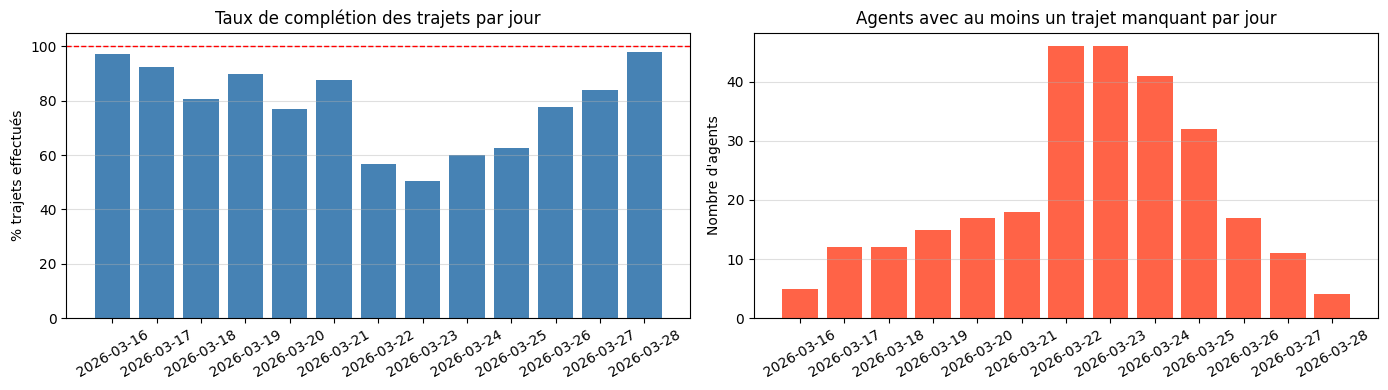

In [9]:
# Visualisation du taux de complétion par jour
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(summary["date"].astype(str), summary["taux_completion_pct"], color="steelblue")
axes[0].axhline(100, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Taux de complétion des trajets par jour")
axes[0].set_ylabel("% trajets effectués")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.4)

axes[1].bar(summary["date"].astype(str), summary["agents_incomplets"], color="tomato")
axes[1].set_title("Agents avec au moins un trajet manquant par jour")
axes[1].set_ylabel("Nombre d'agents")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()


In [10]:
# Agents qui manquent des trajets sur au moins un jour complet
agents_incomplets_df = full_days[full_days["trips_missing"] > 0].copy()

# Résumé par agent : total manquant, nombre de jours concernés
agg_dict_agent = dict(
    jours_incomplets=("date", "nunique"),
    total_trajets_manquants=("trips_missing", "sum"),
    trajets_attendus_par_jour=("trips_expected", "first"),
)
if has_timeout_col:
    agg_dict_agent["total_timeouts"] = ("trips_timed_out", "sum")

agent_summary = (
    agents_incomplets_df
    .groupby("person_id")
    .agg(**agg_dict_agent)
    .sort_values("total_trajets_manquants", ascending=False)
    .reset_index()
)

total_agents = len(expected_per_agent)
total_complete_days = full_days["date"].nunique()
n_ok = total_agents - len(agent_summary)

print(f"Agents avec agenda complet sur tous les jours : {n_ok}/{total_agents}")
print(f"Agents avec au moins un trajet manquant : {len(agent_summary)}/{total_agents}")
print(f"Total trajets manquants sur {total_complete_days} jours complets : {agents_incomplets_df['trips_missing'].sum()}")
if has_timeout_col and "trips_timed_out" in full_days.columns:
    print(f"Total trajets en timeout sur {total_complete_days} jours complets : {full_days['trips_timed_out'].sum()}")

if not agent_summary.empty:
    print("\nAgents les plus incomplets :")
    display(agent_summary.head(20))


Agents avec agenda complet sur tous les jours : 48/100
Agents avec au moins un trajet manquant : 52/100
Total trajets manquants sur 13 jours complets : 999
Total trajets en timeout sur 13 jours complets : 18

Agents les plus incomplets :


,person_id,jours_incomplets,total_trajets_manquants,trajets_attendus_par_jour,total_timeouts
0,544611,13,83,10,1
1,1170603,12,78,11,0
2,824179,11,77,11,0
3,1396214,11,70,10,0
4,1188126,10,60,10,0
5,1170604,10,48,8,0
6,1213591,11,48,8,0
7,386878,9,40,8,0
8,368344,9,40,8,0
9,992607,9,35,7,0
